# Introduction: computing yearly statistics  
This notebooks computes yearly statistics for most of the sensor values. 

In [1]:
from datetime import timedelta
from dateutil.relativedelta import relativedelta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from pathlib import Path
from datetime import datetime, timedelta

# load step 4
path_base = "cache/step4/"
df_dataset = pd.read_parquet(f"{path_base}df_stats_per_day_per_participant.parquet")
df_hot_water_estimates = pd.read_parquet(f"{path_base}df_hot_water_per_participant.parquet")

# load step 2
path_base = "cache/step2/"
df_gas_total = pd.read_parquet(f"{path_base}df_gas_total_no_outliers.parquet")
df_gas_total_unique = pd.read_parquet(f"{path_base}df_gas_total_unique.parquet")
df_elek_total = pd.read_parquet(f"{path_base}df_elek_total_no_outliers_good.parquet")
# df_elek_wrong = pd.read_parquet(f"{path_base}df_elek_wrong.parquet")
df_energy_out_total = pd.read_parquet(f"{path_base}df_energy_out_total_no_outliers.parquet")
df_outside_temp_imputed = pd.read_parquet(f"{path_base}df_outside_temp_imputed.parquet")
print("Loaded cached Dataframes") 

# load from input
path_base = "input/"
df_house = pd.read_csv(f"{path_base}household.csv")
all_participant_ids = df_house['participant_id'].tolist()

Loaded cached Dataframes


# Methodology

**What does not work** <br>
One would believe it's easiest to use the daily data to just sum each day and compute the total consumption that way.

However, as shown in notebook 2_data_cleaning, we had to remove alot of weird 'days'. Meaning we likely do not have all the days in a year, and thus can no longer sum this to get the total. 

**What we do use** <br>
Instead we will use the accumulating total. However, this gives a new problem due to data some times missing, and what if the first and last value are not atleast a year apart? And also, ideally, we would like to look at the same yearly period for all househoulds. However, while most households have data from 2023-2024. Some only have the winter of 2022 to march 2023. Ideally, we pick the same year for most households, but we need to do some concessions. 

- (For the gas sensor only) after taking the daily gas meter sensor read outs we discard any 0 values, we did this in notebook 2.
- We start by looking at the end of 31 march 2024 and look back 365 days, until 31 march 2023 and check if we have a full year of data. If so, use this to calculate consumption. 
- Keep shifting this period by a month and see if you can get a full year of data.
- If we did not find any full year yet, we take the last date, and see if we can go back a little more than 365 days. If so, adjust for the extra days we might include, and use this period instead (slightly longer year due to sensor gaps)
- Finally, if we have less than a year of data we are going to estimate the yearly consumption using the 'bucket method'

## The bucket method 

- First, only for all participants with 365 days of data (this can be a shifted year). 
- Look at each daily temperature and place it in a temperature bucket.
- After filling all the buckets, normalize the data by dividing by the number of participants. 

Now you have a distribution of temperature buckets, and how many days per year the temperature falls within this bucket (on average).

- Let's say the minimum amount of days needs to be atleast 5 days per bucket. With an exception for the lowest bucket of temps below 0, that one does not need any data.
- If we have at least 5 days of data in the bucket, we can compute the average gas consumption that this household would use on such a cold day.
- Now do this average gas consumption per bucket, times the amount of days per bucket and you get an estimate of the yearly gas consumption. 
- For the bucket `<0 Celcius` we can multiply the average gas usage per day to be 2 * `bucket_0_5` 

In [2]:
print(df_dataset)

      participant_id       time  gas_consumption  elek_consumption  \
0           -B51sQOp 2022-06-14              NaN               NaN   
1           -B51sQOp 2022-11-08              NaN               NaN   
2           -B51sQOp 2022-11-09              NaN               NaN   
3           -B51sQOp 2022-11-10            1.036               NaN   
4           -B51sQOp 2022-11-11            0.181               NaN   
...              ...        ...              ...               ...   
92594       zskLB4tU 2024-05-19            0.231             0.226   
92595       zskLB4tU 2024-05-20            0.116             0.226   
92596       zskLB4tU 2024-05-21            0.120             0.225   
92597       zskLB4tU 2024-05-22            0.122             0.228   
92598       zskLB4tU 2024-05-23            0.120             0.227   

       supply_temp  return_temp    flowrate  energy_out is_first_value  \
0              NaN          NaN    0.000000         NaN           None   
1        29

# Yearly Gas Consumption

## Step 1: The unique cases. 
Remember, a few participants had their sensor replaced. As such we manually assigned a period that covers 1 full year (using only the old or new sensor). 

In [3]:
df_gas_total_unique

,participant_id,start_time,end_time
0,uennkFAE,2023-05-02,2024-05-01
1,UkhY0kLf,2023-05-03,2024-05-02
2,6U_ZxCz7,2023-05-02,2024-05-01
3,4iyux5_5,2023-05-05,2024-05-04
4,qAVHYp3J,2022-11-01,2023-11-01
5,uTJqSvxx,2023-05-02,2024-05-01
6,SZphemL4,2022-05-01,2023-05-01


In [4]:
# use start time to calculate yearly consumption 
def calc_gas(x): 
    final_value = 0
    try:
        start_value = df_gas_total[(df_gas_total['participant_id'] == x['participant_id']) & (df_gas_total['time'] == x['start_time'])].iloc[0]['gas_total']
        end_value = df_gas_total[(df_gas_total['participant_id'] == x['participant_id']) & (df_gas_total['time'] == x['end_time'])].iloc[0]['gas_total']
        final_value = end_value - start_value
    except: 
        print(f"Error for {x['participant_id']}")
    return final_value

df_gas_total_unique['gas_consumption_yearly'] = df_gas_total_unique.apply(calc_gas, axis=1)
df_gas_total_unique['days'] = (df_gas_total_unique['end_time'] - df_gas_total_unique['start_time']).dt.days 
df_gas_total_unique['method_gas'] = 'Jaar aan data (Gemeten)'
df_gas_total_unique['note_list'] = df_gas_total_unique.apply(lambda x: ['Slimme meter vervangen'], axis=1)
df_gas_total_unique


,participant_id,start_time,end_time,gas_consumption_yearly,days,method_gas,note_list
0,uennkFAE,2023-05-02,2024-05-01,569.900,365,Jaar aan data (Gemeten),[Slimme meter vervangen]
1,UkhY0kLf,2023-05-03,2024-05-02,148.090,365,Jaar aan data (Gemeten),[Slimme meter vervangen]
2,6U_ZxCz7,2023-05-02,2024-05-01,284.019,365,Jaar aan data (Gemeten),[Slimme meter vervangen]
3,4iyux5_5,2023-05-05,2024-05-04,473.633,365,Jaar aan data (Gemeten),[Slimme meter vervangen]
4,qAVHYp3J,2022-11-01,2023-11-01,943.437,365,Jaar aan data (Gemeten),[Slimme meter vervangen]
5,uTJqSvxx,2023-05-02,2024-05-01,461.952,365,Jaar aan data (Gemeten),[Slimme meter vervangen]
6,SZphemL4,2022-05-01,2023-05-01,261.067,365,Jaar aan data (Gemeten),[Slimme meter vervangen]


## Step 2: participants with atleast a year of data


In [5]:
df_same_start = df_gas_total[df_gas_total['time'] < datetime(2024,6,1)] 

df2 = df_same_start[~df_same_start['participant_id'].isin(df_gas_total_unique['participant_id'])] # take out the unique cases 
gb = df2.groupby('participant_id')

# Step 1: Calculate the days between first and last sensor value.
# Split in two groups: ids with 365+ days or those with less than a year of data.
def split_atleast_year_of_data(grouped_df): 
    gb = grouped_df
    print(f'Starting with {len(gb)} ids')
    df = gb.agg({'time': ['min', 'max']})
    df['nr_day_diff'] = df['time']['max']-df['time']['min']
    df['nr_day_diff'] = df['nr_day_diff'].dt.days

    bakjes_ids = df[df['nr_day_diff'] < 365].index
    year_ids = df[df['nr_day_diff'] >= 365].index
    print(f'{len(bakjes_ids)} ids for bakjes methode')
    print(f'{len(year_ids)} ids with atleast year of gas data')
    return year_ids, bakjes_ids

# Step 2: Only for the IDs with a year of data: find a period of 365 days.
# First: Let's see if we can start from 2024-04-30 and look back and see if we have a year of data.
# Repeat this for a few months.
# If we still could not find an exact period of 365 days. Then take the first day outside of this 365 interval, and adjust for the slightly bigger interval.
def find_a_year_of_data(df_in, col_name): 
    # df = df_in[['time', 'participant_id', col_name]]
    data = [] 

    for name, df_sub in df_in.groupby('participant_id'): 
        end_date = datetime(2024, 4, 30)
        start_date = end_date - timedelta(days=365)
        found_year = False

        while end_date > datetime(2023, 8, 30):
            df_start_date = df_sub[df_sub['time'] == start_date]
            df_end_date = df_sub[df_sub['time'] == end_date] 
            if len(df_start_date) == 1 and len(df_end_date) == 1:
                # Exactly 365 days ago we found a matching record.
                found_year = True
                start_value = df_start_date.iloc[0][col_name]
                end_value = df_end_date.iloc[0][col_name]

                data.append({'participant_id': name, 
                                    'start_time': start_date, 
                                    'end_time': end_date, 
                                    'days': (end_date-start_date).days,
                                    'start_value': start_value,
                                    'end_value': end_value,
                                    'yearly_total': end_value-start_value
                                   })
                break
            else: 
                # try again, but for a month earlier.
                end_date = end_date - relativedelta(months=1)
                start_date = end_date - timedelta(days=365)
        if not found_year: 
            # If we did not find a record 365 days ago, we look at the last day the sensor reported a value.
            # We then filter on all the days that are more than 365days ago and pick the one that is the least old.
            # This way we end up with a slightly bigger interval than 365 days. However, usually only by 1 or 2 days.
            # We adjust the total

            print(f'{name} did not find exact 365 days based on first day of month, attempting smallest possible range from last day')

            end_date = df_sub['time'].max() # end date of year interval

            df_filter = df_sub[
                (df_sub["time"]
                >= (end_date - timedelta(days=365))) 
                & (df_sub["time"] <= end_date)
            ]  # find all days in a year before. 

            start_row = df_filter.iloc[0]  # select the earliest possible date
            day_diff = (end_date-start_row['time']).days
            adjust_ratio = 365/day_diff
            end_value = df_sub[df_sub['time'] == end_date].iloc[0][col_name]
            start_value = start_row[col_name]

            gas_consumption = end_value - start_value
            gas_consumption_adjusted = gas_consumption * adjust_ratio # adjust for the fact we took a period with more days 
            new = {'participant_id': name,
                                'start_time': start_row['time'],
                                'end_time': end_date,
                                'days': day_diff,
                                'start_value': start_value,
                                'end_value': end_value, 
                                'yearly_total': gas_consumption_adjusted
                               }
            print(f'Managed to find a date range of {day_diff} days, adjusted accordingly')
            data.append(new)

    return pd.DataFrame(data)


year_ids, bakjes_ids = split_atleast_year_of_data(gb)

df_year_of_data = df_gas_total[df_gas_total['participant_id'].isin(year_ids)]

df_yearly_gas = find_a_year_of_data(df_year_of_data, 'gas_total') 
df_yearly_gas = df_yearly_gas.rename(columns={'yearly_total': 'gas_consumption_yearly'})
df_yearly_gas['method_gas'] = 'Jaar aan data (Gemeten)'
df_yearly_gas

Starting with 167 ids
12 ids for bakjes methode
155 ids with atleast year of gas data
-ORiFQC6 did not find exact 365 days based on first day of month, attempting smallest possible range from last day
Managed to find a date range of 365 days, adjusted accordingly
0RQyG6WX did not find exact 365 days based on first day of month, attempting smallest possible range from last day
Managed to find a date range of 365 days, adjusted accordingly
1Y5XKgSd did not find exact 365 days based on first day of month, attempting smallest possible range from last day
Managed to find a date range of 284 days, adjusted accordingly
66lZ2dKl did not find exact 365 days based on first day of month, attempting smallest possible range from last day
Managed to find a date range of 32 days, adjusted accordingly
6pd9A10u did not find exact 365 days based on first day of month, attempting smallest possible range from last day
Managed to find a date range of 296 days, adjusted accordingly
CbPETsjw did not find exa

,participant_id,start_time,end_time,days,start_value,end_value,gas_consumption_yearly,method_gas
0,-B51sQOp,2022-12-29,2023-12-29,365,5070.436,5393.656,323.220000,Jaar aan data (Gemeten)
1,-ORiFQC6,2022-07-30,2023-07-30,365,2240.690,2384.610,143.920000,Jaar aan data (Gemeten)
2,-uFUg8jU,2023-05-01,2024-04-30,365,5510.986,6430.617,919.631000,Jaar aan data (Gemeten)
3,0RQyG6WX,2022-05-10,2023-05-10,365,12365.229,12939.385,574.156000,Jaar aan data (Gemeten)
4,0XvCtU3v,2023-03-31,2024-03-30,365,7462.470,7782.724,320.254000,Jaar aan data (Gemeten)
...,...,...,...,...,...,...,...,...
150,ywCyyxQF,2023-05-01,2024-04-30,365,7785.095,8430.280,645.185000,Jaar aan data (Gemeten)
151,yxOWx66O,2023-05-01,2024-04-30,365,5882.766,6022.492,139.726000,Jaar aan data (Gemeten)
152,zK4WxULP,2023-01-29,2024-01-29,365,5485.010,5938.676,453.666000,Jaar aan data (Gemeten)
153,zPZ3d57M,2023-05-01,2024-04-30,365,4560.083,5039.976,479.893000,Jaar aan data (Gemeten)


Now all that's left is estimating the yearly consumption for households with sensor readings less than 365 days apart.


## Preperation for bakjes method
Compute relationship between different bakjes: Sometimes a bucket might not have data at all, then we the following info 'how much is the difference between buckets on average (using the households that do have data)'

In [6]:
# df_heatpump_active = df_dataset[(df_dataset['time'] <= datetime(2024,4,30)) & (df_dataset['time'] >= datetime(2023,5,1)) & (df_dataset['elek_consumption'] > 1)]

df3 = df_dataset[df_dataset.time <= datetime(2024,5,31)]
df4 = df3[['time', 'participant_id', 'outside_temp', 'gas_consumption_heating']].merge(df_house[['participant_id', 'surface']], on='participant_id', how='left')

# we also adjust for the fact that amount of gas consumed has a strong correlation with m2 of the house (we try to remove the effect) 
# df4['gas_per_m2'] = df4['gas_consumption_heating'] / df4['surface']

column_temp = 'outside_temp'

df4['bucket'] = np.where(df4[column_temp] <= 0, 'bucket_0',
                    np.where((df4[column_temp] <= 5), 'bucket_0_5', 
                             np.where((df4[column_temp] <= 10), 'bucket_5_10',
                                      np.where((df4[column_temp] <= 15), 'bucket_10_15', 'bucket_15'))))  
df_list = []


result = df4.groupby('bucket')['gas_consumption_heating'].agg(['count', 'mean'])
print(result)
print(result.loc['bucket_10_15', 'mean'])
bucket_ratio_15_and_10_15 = result.loc['bucket_10_15', 'mean'] / result.loc['bucket_15', 'mean']
bucket_ratio_10_15_and_5_10 = result.loc['bucket_5_10', 'mean'] / result.loc['bucket_10_15', 'mean']    
bucket_ratio_5_10_and_0_5 = result.loc['bucket_0_5', 'mean'] / result.loc['bucket_5_10', 'mean']
bucket_ratio_0_5_and_0 = result.loc['bucket_0', 'mean'] / result.loc['bucket_0_5', 'mean']
print(bucket_ratio_15_and_10_15, bucket_ratio_10_15_and_5_10, bucket_ratio_5_10_and_0_5, bucket_ratio_0_5_and_0)
# pretty interestingly, the consumption in bucket 15 is higher than bucket between 10 & 15 
# we will use these ratios in cases buckets are missing 
bucket_result = result
#df2.loc[df2['gas_total'] == 114]


              count      mean
bucket                       
bucket_0       2936  5.880293
bucket_0_5    10699  2.887591
bucket_10_15  20264  0.481143
bucket_15     24991  0.158186
bucket_5_10   26134  1.075048
0.4811429749970583
3.041623586346778 2.234362766796011 2.6860111701169633 2.0364012267827434


<Axes: xlabel='surface', ylabel='gas_consumption_heating'>

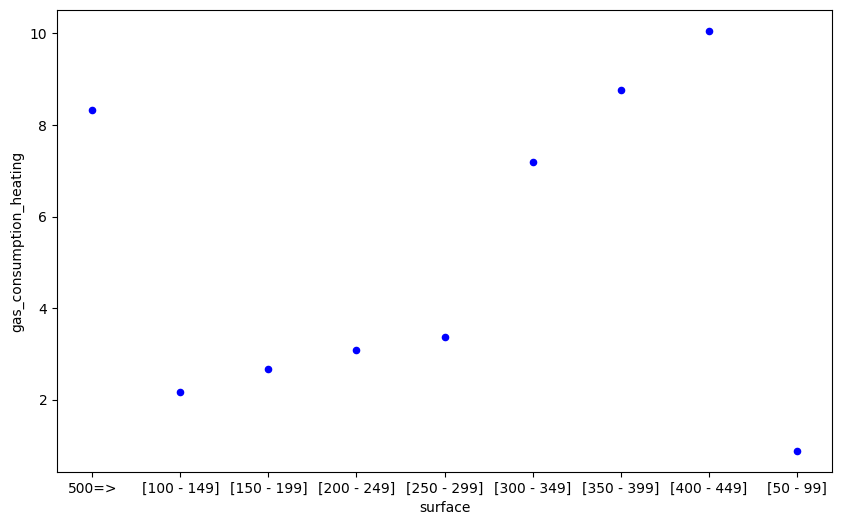

In [7]:
df4[df4['bucket']=='bucket_0_5'].groupby('surface')['gas_consumption_heating'].mean().reset_index().plot(kind='scatter', x='surface', y='gas_consumption_heating', figsize=(10, 6), color='blue')
# on average, the bigger the surface area, the more gas_consumption for the same temperature

In [8]:
#bakjes_ids
#df_heatpump_active = df_dataset[(df_dataset['elek_consumption'] > 1)] # (df_dataset['time'] <= datetime(2024,4,30)) & (df_dataset['time'] >= datetime(2023,5,1)) &

df_bakjes = df_dataset[df_dataset['participant_id'].isin(bakjes_ids)].copy()
column_temp = 'outside_temp'
df_bakjes['bucket'] = np.where(df_bakjes[column_temp] <= 0, 'bucket_0',
                            np.where((df_bakjes[column_temp] <= 5), 'bucket_0_5', 
                             np.where((df_bakjes[column_temp] <= 10), 'bucket_5_10',
                                      np.where((df_bakjes[column_temp] <= 15), 'bucket_10_15', 'bucket_15'))))  

df_bakjes_avg = df_bakjes.groupby(['participant_id', 'bucket'])['gas_consumption_heating'].agg(['count', 'mean'])
df_bakjes_avg

count       mean
participant_id bucket                        
141Q2Shj       bucket_0         15   8.024596
               bucket_0_5       41   4.505945
               bucket_10_15     55   0.419270
               bucket_15        90   0.096456
               bucket_5_10      65   1.528262
7JgOwuUh       bucket_0         16   3.355661
               bucket_0_5       50   1.761331
               bucket_10_15     60   0.463226
               bucket_15        14   0.034735
               bucket_5_10      84   0.958268
9H8W2b5Q       bucket_0         12   8.759536
               bucket_0_5       44   2.243632
               bucket_10_15     35   0.393713
               bucket_15         0        NaN
               bucket_5_10      78   0.655051
IF9c6c-H       bucket_0          0        NaN
               bucket_0_5        0        NaN
               bucket_10_15      0        NaN
               bucket_15         2   0.000000
               bucket_5_10       0        NaN
Jr9PJjgK       bucket_0          0        NaN
               bucket_0_5        0        NaN
               bucket_10_15      0        NaN
               bucket_15         0        NaN
               bucket_5_10       0        NaN
KR2H1ovj       bucket_10_15     33   0.231777
               bucket_15        73   0.148498
               bucket_5_10      11   0.290077
PL238TVN       bucket_0          1  12.863884
               bucket_0_5       32   7.913446
               bucket_10_15     44   1.049926
               bucket_15        42   0.236937
               bucket_5_10      49   2.945252
UigJRsPF       bucket_0         14   6.084238
               bucket_0_5       49   3.511014
               bucket_10_15     62   0.721118
               bucket_15        33   0.173323
               bucket_5_10      88   1.546788
gmtO-ZIa       bucket_0          0        NaN
               bucket_0_5        0        NaN
               bucket_10_15      0        NaN
               bucket_15         0        NaN
               bucket_5_10       0        NaN
qBr4JQ_w       bucket_0         12   0.000000
               bucket_0_5       64   0.000000
               bucket_10_15     83   0.000000
               bucket_15        24   0.000000
               bucket_5_10     186   0.000000
uQLTOCT9       bucket_15         0        NaN
ueGJf9d5       bucket_0          0        NaN
               bucket_0_5        0        NaN
               bucket_10_15      0        NaN
               bucket_15         0        NaN
               bucket_5_10       0        NaN

## Step 3: bucketmethod / bakjesmethode

In [9]:
# calculate totals 
def bucket_method(df_bakjes_avg): 
    """
    df_in = Averages per bucket per participant
    """
    data_list = []
    filled_buckets_list = []
    for id, df_sub in df_bakjes_avg.groupby('participant_id'): 
        df_sub = df_sub.droplevel('participant_id') # df (single participant), averages per bucket 
        filled_buckets = df_sub[df_sub['count'] >= 2].copy() # need at least 2 days in a bucket 

        check = len(df_sub)
        total = df_sub['count'].sum()
        if total < 20: 
            print(id, 'Too little records for bakjes method, need at least 20 days')
            data_list.append({'participant_id': id, 'yearly_total': np.nan, 'method': 'Nvt. Te weinig data stookseizoen'})
            continue 

        missing_buckets = list(set(['bucket_0', 'bucket_0_5', 'bucket_5_10', 'bucket_10_15', 'bucket_15']) - set(filled_buckets.index.values))
        
        SORT_ORDER = {"bucket_0": 0,"bucket_0_5":1, "bucket_10_15": 2, "bucket_15": 3}
        missing_buckets.sort(key=lambda val: SORT_ORDER[val], reverse=True) # sort inplace, highest val first 
        
        if len(missing_buckets) > 1 and missing_buckets[0] == 'bucket_15':
            # revert sort if actually two buckets are missing 
            missing_buckets.sort(key=lambda val: SORT_ORDER[val]) 
            
        if missing_buckets != None:
            for bucket in missing_buckets:
                # based on our tests, it's usually bucket_0, bucket_10_15 and bucket_15 that are empty
                if bucket == 'bucket_0': 
                    filled_buckets.loc['bucket_0', 'mean'] = filled_buckets.loc['bucket_0_5', 'mean'] * bucket_ratio_0_5_and_0 # use slightly warmer bucket
                elif bucket == 'bucket_0_5': 
                    if 'bucket_0' not in missing_buckets: 
                        filled_buckets.loc['bucket_0_5', 'mean'] = filled_buckets.loc['bucket_0', 'mean'] / bucket_ratio_0_5_and_0 # use slightly colder bucket
                    else: 
                        filled_buckets.loc['bucket_0_5', 'mean'] = filled_buckets.loc['bucket_5_10', 'mean'] * bucket_ratio_5_10_and_0_5 # use slightly warmer bucket
                elif bucket == 'bucket_10_15': 
                    filled_buckets.loc['bucket_10_15', 'mean'] = filled_buckets.loc['bucket_5_10', 'mean'] / bucket_ratio_10_15_and_5_10 # use slightly colder bucket, so now it's divide instead
                elif bucket == 'bucket_15': 
                    filled_buckets.loc['bucket_15', 'mean'] = filled_buckets.loc['bucket_10_15', 'mean'] / bucket_ratio_15_and_10_15 # use slightly colder bucket, so now it's divide instead

        if len(filled_buckets) != 5: 
            print('ERROR should have 5 buckets')

        # caclulate total per bucket
        # we base the average days per year per bucket on data from De Bilt, Utrecht 
        total_year = (filled_buckets.loc['bucket_0', 'mean'] * 12 +  
        filled_buckets.loc['bucket_0_5', 'mean'] * 51 + 
        filled_buckets.loc['bucket_5_10', 'mean'] * 100 +  
        filled_buckets.loc['bucket_10_15', 'mean'] * 90 + 
        filled_buckets.loc['bucket_15', 'mean'] * 112)

        filled_buckets['participant_id'] = id
        filled_buckets_list.append(filled_buckets)
        data_list.append({'participant_id': id, 'yearly_total': total_year, 'days': total, 'method': 'Bakjesmethode (Schatting)'}) 

    
    df_bakjes_yearly = pd.DataFrame(data_list) # estimated yearly consumption per participant 
    df_filled_buckets = pd.concat(filled_buckets_list) # dataframe with average consumption per bucket, per participant 
    
    return df_bakjes_yearly, df_filled_buckets

df_bakjes_yearly, df_filled_buckets = bucket_method(df_bakjes_avg) 
df_bakjes_yearly = df_bakjes_yearly.rename(columns={'method': 'method_gas', 'yearly_total': 'gas_consumption_yearly'})
#print(df_filled_buckets) 
print(df_bakjes_yearly) # most imporant one 

IF9c6c-H Too little records for bakjes method, need at least 20 days
Jr9PJjgK Too little records for bakjes method, need at least 20 days
gmtO-ZIa Too little records for bakjes method, need at least 20 days
uQLTOCT9 Too little records for bakjes method, need at least 20 days
ueGJf9d5 Too little records for bakjes method, need at least 20 days
   participant_id  gas_consumption_yearly   days  \
0        141Q2Shj              527.461895  266.0   
1        7JgOwuUh              271.503278  224.0   
2        9H8W2b5Q              334.976407  169.0   
3        IF9c6c-H                     NaN    NaN   
4        Jr9PJjgK                     NaN    NaN   
5        KR2H1ovj              125.276231  117.0   
6        PL238TVN             1012.520711  168.0   
7        UigJRsPF              491.064186  246.0   
8        gmtO-ZIa                     NaN    NaN   
9        qBr4JQ_w                0.000000  369.0   
10       uQLTOCT9                     NaN    NaN   
11       ueGJf9d5              

In [10]:
df_bakjes_yearly

,participant_id,gas_consumption_yearly,days,method_gas
0,141Q2Shj,527.461895,266.0,Bakjesmethode (Schatting)
1,7JgOwuUh,271.503278,224.0,Bakjesmethode (Schatting)
2,9H8W2b5Q,334.976407,169.0,Bakjesmethode (Schatting)
3,IF9c6c-H,NaN,NaN,Nvt. Te weinig data stookseizoen
4,Jr9PJjgK,NaN,NaN,Nvt. Te weinig data stookseizoen
5,KR2H1ovj,125.276231,117.0,Bakjesmethode (Schatting)
6,PL238TVN,1012.520711,168.0,Bakjesmethode (Schatting)
7,UigJRsPF,491.064186,246.0,Bakjesmethode (Schatting)
8,gmtO-ZIa,NaN,NaN,Nvt. Te weinig data stookseizoen
9,qBr4JQ_w,0.000000,369.0,Bakjesmethode (Schatting)


In [35]:
#If you want to check the buckets of specific participant_id'
#df_filled_buckets[df_filled_buckets['participant_id'] == 'wV6kb6BJ']

In [11]:
df_final_yearly_gas = pd.concat([df_yearly_gas, df_gas_total_unique, df_bakjes_yearly], ignore_index=True)
df_final_yearly_gas

,participant_id,start_time,end_time,days,start_value,end_value,gas_consumption_yearly,method_gas,note_list
0,-B51sQOp,2022-12-29,2023-12-29,365.0,5070.436,5393.656,323.220000,Jaar aan data (Gemeten),NaN
1,-ORiFQC6,2022-07-30,2023-07-30,365.0,2240.690,2384.610,143.920000,Jaar aan data (Gemeten),NaN
2,-uFUg8jU,2023-05-01,2024-04-30,365.0,5510.986,6430.617,919.631000,Jaar aan data (Gemeten),NaN
3,0RQyG6WX,2022-05-10,2023-05-10,365.0,12365.229,12939.385,574.156000,Jaar aan data (Gemeten),NaN
4,0XvCtU3v,2023-03-31,2024-03-30,365.0,7462.470,7782.724,320.254000,Jaar aan data (Gemeten),NaN
...,...,...,...,...,...,...,...,...,...
169,UigJRsPF,NaT,NaT,246.0,NaN,NaN,491.064186,Bakjesmethode (Schatting),NaN
170,gmtO-ZIa,NaT,NaT,NaN,NaN,NaN,NaN,Nvt. Te weinig data stookseizoen,NaN
171,qBr4JQ_w,NaT,NaT,369.0,NaN,NaN,0.000000,Bakjesmethode (Schatting),NaN
172,uQLTOCT9,NaT,NaT,NaN,NaN,NaN,NaN,Nvt. Te weinig data stookseizoen,NaN


# Estimate yearly elektricity usage heatpump 

For the elektricity usage, we already filtered out the invalid values of the households in Notebook 2. As such we can start with first step rightaway.

## Step 1: atleast a year of data
Let's use the same method as with Gas consumption, and again try to fix are end date to 2024-05-31

In [12]:
df_same_start = df_elek_total[df_elek_total['time'] < datetime(2024,6,1)] 

#df2 = df_same_start[~df_same_start['participant_id'].isin(df_unique['participant_id'])] # no need to filter, only needed for gas
gb = df_same_start.groupby('participant_id')

# Step 1: Split in two groups: ids with 365+ days or those with less than a year of data. 
year_ids, bakjes_ids = split_atleast_year_of_data(gb) 

df_year_of_data = df_elek_total[df_elek_total['participant_id'].isin(year_ids)]

# Step 2: Only for the IDs with a year of data: find a period of 365 days.
df_yearly_elek = find_a_year_of_data(df_year_of_data, 'electricity_total') 
df_yearly_elek = df_yearly_elek.rename(columns={'yearly_total': 'elek_consumption_yearly'})
df_yearly_elek['method_elek'] = 'Jaar aan data (Gemeten)'
df_yearly_elek

Starting with 134 ids
12 ids for bakjes methode
122 ids with atleast year of gas data
-ORiFQC6 did not find exact 365 days based on first day of month, attempting smallest possible range from last day
Managed to find a date range of 365 days, adjusted accordingly
0RQyG6WX did not find exact 365 days based on first day of month, attempting smallest possible range from last day
Managed to find a date range of 365 days, adjusted accordingly
66lZ2dKl did not find exact 365 days based on first day of month, attempting smallest possible range from last day
Managed to find a date range of 32 days, adjusted accordingly
D8ZSj9yG did not find exact 365 days based on first day of month, attempting smallest possible range from last day
Managed to find a date range of 365 days, adjusted accordingly
DlCdUGP1 did not find exact 365 days based on first day of month, attempting smallest possible range from last day
Managed to find a date range of 365 days, adjusted accordingly
EyZIyLSP did not find exa

,participant_id,start_time,end_time,days,start_value,end_value,elek_consumption_yearly,method_elek
0,-ORiFQC6,2022-07-30,2023-07-30,365,589.593,2853.627,2264.034000,Jaar aan data (Gemeten)
1,-uFUg8jU,2023-05-01,2024-04-30,365,3488.744,6614.932,3126.188000,Jaar aan data (Gemeten)
2,0RQyG6WX,2022-05-10,2023-05-10,365,771.041,3210.633,2439.592000,Jaar aan data (Gemeten)
3,0XvCtU3v,2023-03-31,2024-03-30,365,1485.761,2995.927,1510.166000,Jaar aan data (Gemeten)
4,0_6TUlP4,2023-05-01,2024-04-30,365,1487.791,2991.463,1503.672000,Jaar aan data (Gemeten)
...,...,...,...,...,...,...,...,...
117,yjpSQKFb,2023-05-01,2024-04-30,365,2167.335,4769.594,2602.259000,Jaar aan data (Gemeten)
118,yxOWx66O,2023-05-01,2024-04-30,365,1219.713,2685.014,1465.301000,Jaar aan data (Gemeten)
119,zK4WxULP,2023-01-29,2024-01-29,365,340.717,2106.974,1766.257000,Jaar aan data (Gemeten)
120,zPZ3d57M,2023-05-01,2024-04-30,365,2439.449,4532.956,2093.507000,Jaar aan data (Gemeten)


## Preperation for bakjes method

In [13]:
# bakjes_ids
df_heatpump_active = df_dataset[(df_dataset['elek_consumption'] > 1)] # (df_dataset['time'] <= datetime(2024,4,30)) & (df_dataset['time'] >= datetime(2023,5,1)) &

df_bakjes = df_dataset[(df_dataset['participant_id'].isin(bakjes_ids)) & (df_dataset['time'] <= datetime(2024,5,31))].copy()

df_bakjes
column_temp = 'outside_temp'
df_bakjes['bucket'] = np.where(df_bakjes[column_temp] <= 0, 'bucket_0',
                            np.where((df_bakjes[column_temp] <= 5), 'bucket_0_5', 
                             np.where((df_bakjes[column_temp] <= 10), 'bucket_5_10',
                                      np.where((df_bakjes[column_temp] <= 15), 'bucket_10_15', 'bucket_15'))))  

df_bakjes_avg = df_bakjes.groupby(['participant_id', 'bucket']).agg(['count', 'mean'])['elek_consumption']
df_bakjes_avg

count       mean
participant_id bucket                        
141Q2Shj       bucket_0         15  15.239267
               bucket_0_5       41  14.265756
               bucket_10_15     55   4.892273
               bucket_15        90   0.349567
               bucket_5_10      65  11.669400
7JgOwuUh       bucket_0         16  12.674375
               bucket_0_5       50  12.029420
               bucket_10_15     60   4.344567
               bucket_15        14   1.473857
               bucket_5_10      84   6.908869
JEZzJ1_-       bucket_0          9  41.373333
               bucket_0_5       24  25.279292
               bucket_10_15     33   8.603879
               bucket_15        15   2.023533
               bucket_5_10      84  15.429393
MNbpwIxe       bucket_0          8  47.516875
               bucket_0_5       19  28.174947
               bucket_10_15     41   6.791463
               bucket_15        22   1.419273
               bucket_5_10      66  15.853924
OMa7vZ0x       bucket_0          9  47.586444
               bucket_0_5       21  27.883762
               bucket_10_15     34   8.481618
               bucket_15        30   2.192133
               bucket_5_10      82  15.297524
PL238TVN       bucket_0          1   2.692000
               bucket_0_5       32  15.826906
               bucket_10_15     44   7.135068
               bucket_15        42   0.875476
               bucket_5_10      49  14.196204
UigJRsPF       bucket_0         14  13.601214
               bucket_0_5       49  14.244265
               bucket_10_15     64   2.976875
               bucket_15        33   0.367636
               bucket_5_10      88   8.106443
WUAgbEiI       bucket_0          9  40.181889
               bucket_0_5       24  23.772667
               bucket_10_15     30   9.245967
               bucket_15        27   1.214037
               bucket_5_10      81  16.968111
bW_iJrKG       bucket_0          9  41.489333
               bucket_0_5       20  23.999000
               bucket_10_15     38   7.174053
               bucket_15        22   1.946182
               bucket_5_10      81  12.882630
cXHtdNjQ       bucket_0          9  50.422667
               bucket_0_5       20  26.871300
               bucket_10_15     34   9.077941
               bucket_15        18   2.479278
               bucket_5_10      78  15.165859
sNLALR1w       bucket_0          9  39.618000
               bucket_0_5       24  23.567583
               bucket_10_15     30   7.838633
               bucket_15        27   2.082000
               bucket_5_10      80  13.722500
uQLTOCT9       bucket_15         0        NaN

## Step 2: bucketmethod / bakjesmethode

In [14]:
df_bakjes_yearly, df_filled_buckets = bucket_method(df_bakjes_avg) 
df_bakjes_yearly = df_bakjes_yearly.rename(columns={'method': 'method_elek', 'yearly_total': 'elek_consumption_yearly'})
df_bakjes_yearly # most imporant one 

uQLTOCT9 Too little records for bakjes method, need at least 20 days


,participant_id,elek_consumption_yearly,days,method_elek
0,141Q2Shj,2556.820773,266.0,Bakjesmethode (Schatting)
1,7JgOwuUh,2012.562825,224.0,Bakjesmethode (Schatting)
2,JEZzJ1_-,4329.647985,165.0,Bakjesmethode (Schatting)
3,MNbpwIxe,4362.707493,156.0,Bakjesmethode (Schatting)
4,OMa7vZ0x,4531.726151,176.0,Bakjesmethode (Schatting)
5,PL238TVN,3353.761272,168.0,Bakjesmethode (Schatting)
6,UigJRsPF,2009.410443,248.0,Bakjesmethode (Schatting)
7,WUAgbEiI,4359.508926,171.0,Bakjesmethode (Schatting)
8,bW_iJrKG,3873.721063,170.0,Bakjesmethode (Schatting)
9,cXHtdNjQ,4586.788014,159.0,Bakjesmethode (Schatting)


In [15]:
df_yearly_elek_final = pd.concat([df_yearly_elek, df_bakjes_yearly], ignore_index=True)
df_yearly_elek_final

,participant_id,start_time,end_time,days,start_value,end_value,elek_consumption_yearly,method_elek
0,-ORiFQC6,2022-07-30,2023-07-30,365.0,589.593,2853.627,2264.034000,Jaar aan data (Gemeten)
1,-uFUg8jU,2023-05-01,2024-04-30,365.0,3488.744,6614.932,3126.188000,Jaar aan data (Gemeten)
2,0RQyG6WX,2022-05-10,2023-05-10,365.0,771.041,3210.633,2439.592000,Jaar aan data (Gemeten)
3,0XvCtU3v,2023-03-31,2024-03-30,365.0,1485.761,2995.927,1510.166000,Jaar aan data (Gemeten)
4,0_6TUlP4,2023-05-01,2024-04-30,365.0,1487.791,2991.463,1503.672000,Jaar aan data (Gemeten)
...,...,...,...,...,...,...,...,...
129,WUAgbEiI,NaT,NaT,171.0,NaN,NaN,4359.508926,Bakjesmethode (Schatting)
130,bW_iJrKG,NaT,NaT,170.0,NaN,NaN,3873.721063,Bakjesmethode (Schatting)
131,cXHtdNjQ,NaT,NaT,159.0,NaN,NaN,4586.788014,Bakjesmethode (Schatting)
132,sNLALR1w,NaT,NaT,170.0,NaN,NaN,3988.273750,Bakjesmethode (Schatting)


# Estimate yearly energy out / kamstrup

## Step 1: atleast a year of data
Same method as before, try to fix the end date to 2024-05-31

In [16]:
df_same_start = df_energy_out_total[df_energy_out_total['time'] < datetime.strptime("2024-06-01", "%Y-%m-%d")] 

#df2 = df_same_start[~df_same_start['participant_id'].isin(df_unique['participant_id # only needed this filter for gas
gb = df_same_start.groupby('participant_id')

# Step 1: Split in two groups: ids with 365+ days or those with less than a year of data. 
year_ids, bakjes_ids = split_atleast_year_of_data(gb)

df_year_of_data = df_energy_out_total[df_energy_out_total['participant_id'].isin(year_ids)]

# Step 2: Only for the IDs with a year of data: find a period of 365 days.
df_yearly_energy_out = find_a_year_of_data(df_year_of_data, 'energy_out_total') 
df_yearly_energy_out = df_yearly_energy_out.rename(columns={'yearly_total': 'energy_out_yearly'})
df_yearly_energy_out['method_energy_out'] = 'Jaar aan data (Gemeten)'
df_yearly_energy_out

Starting with 174 ids
7 ids for bakjes methode
167 ids with atleast year of gas data
-ORiFQC6 did not find exact 365 days based on first day of month, attempting smallest possible range from last day
Managed to find a date range of 365 days, adjusted accordingly
0RQyG6WX did not find exact 365 days based on first day of month, attempting smallest possible range from last day
Managed to find a date range of 365 days, adjusted accordingly
66lZ2dKl did not find exact 365 days based on first day of month, attempting smallest possible range from last day
Managed to find a date range of 32 days, adjusted accordingly
6pd9A10u did not find exact 365 days based on first day of month, attempting smallest possible range from last day
Managed to find a date range of 296 days, adjusted accordingly
D8ZSj9yG did not find exact 365 days based on first day of month, attempting smallest possible range from last day
Managed to find a date range of 365 days, adjusted accordingly
DlCdUGP1 did not find exac

,participant_id,start_time,end_time,days,start_value,end_value,energy_out_yearly,method_energy_out
0,-B51sQOp,2022-12-29,2023-12-29,365,4479.528356,20455.007508,15975.479151,Jaar aan data (Gemeten)
1,-ORiFQC6,2022-07-30,2023-07-30,365,2269.565972,10640.849673,8371.283701,Jaar aan data (Gemeten)
2,-uFUg8jU,2023-05-01,2024-04-30,365,15271.793981,30632.445023,15360.651042,Jaar aan data (Gemeten)
3,0RQyG6WX,2022-05-10,2023-05-10,365,4383.333333,17918.510802,13535.177469,Jaar aan data (Gemeten)
4,0XvCtU3v,2023-03-31,2024-03-30,365,49.166667,83.888889,34.722222,Jaar aan data (Gemeten)
...,...,...,...,...,...,...,...,...
162,ywCyyxQF,2023-05-01,2024-04-30,365,10462.320602,25253.564815,14791.244213,Jaar aan data (Gemeten)
163,yxOWx66O,2023-05-01,2024-04-30,365,6799.305556,15135.228588,8335.923032,Jaar aan data (Gemeten)
164,zK4WxULP,2023-01-29,2024-01-29,365,1990.020255,11601.684028,9611.663773,Jaar aan data (Gemeten)
165,zPZ3d57M,2023-05-01,2024-04-30,365,10218.897569,19106.047454,8887.149884,Jaar aan data (Gemeten)


## Preperation for bakjes method

In [17]:
#bakjes_ids
df_heatpump_active = df_dataset[(df_dataset['elek_consumption'] > 1)] # (df_dataset['time'] <= datetime(2024,4,30)) & (df_dataset['time'] >= datetime(2023,5,1)) &

df_bakjes = df_heatpump_active[df_heatpump_active['participant_id'].isin(bakjes_ids)].copy() 
column_temp = 'outside_temp'
df_bakjes['bucket'] = np.where(df_bakjes[column_temp] <= 0, 'bucket_0',
                            np.where((df_bakjes[column_temp] <= 5), 'bucket_0_5', 
                             np.where((df_bakjes[column_temp] <= 10), 'bucket_5_10',
                                      np.where((df_bakjes[column_temp] <= 15), 'bucket_10_15', 'bucket_15'))))  

df_bakjes_avg = df_bakjes.groupby(['participant_id', 'bucket']).agg(['count', 'mean'])['energy_out']
df_bakjes_avg

count        mean
participant_id bucket                         
141Q2Shj       bucket_0         15   56.639333
               bucket_0_5       41   43.445366
               bucket_10_15     30   16.647333
               bucket_15         2   13.255000
               bucket_5_10      65   27.306154
7JgOwuUh       bucket_0         14   64.088571
               bucket_0_5       50   50.709600
               bucket_10_15     51   20.432157
               bucket_15         8    8.082500
               bucket_5_10      80   32.535000
PL238TVN       bucket_0          1   99.870000
               bucket_0_5       31  120.863548
               bucket_10_15     30   45.631000
               bucket_15         4   24.535000
               bucket_5_10      48   81.811667
UigJRsPF       bucket_0         12   93.180833
               bucket_0_5       39   81.812308
               bucket_10_15     27   30.493704
               bucket_15         3    8.076667
               bucket_5_10      69   51.886232

## Step 2: bucketmethod / bakjesmethode

In [18]:
df_bakjes_yearly, df_filled_buckets = bucket_method(df_bakjes_avg) 
df_bakjes_yearly = df_bakjes_yearly.rename(columns={'method': 'method_energy_out', 'yearly_total': 'energy_out_yearly'})
print(df_bakjes_yearly)

  participant_id  energy_out_yearly  days          method_energy_out
0       141Q2Shj        8608.821043   153  Bakjesmethode (Schatting)
1       7JgOwuUh        9352.886575   203  Bakjesmethode (Schatting)
2       PL238TVN       24153.437773   114  Bakjesmethode (Schatting)
3       UigJRsPF       14128.240881   150  Bakjesmethode (Schatting)


In [19]:
df_yearly_energy_out_final = pd.concat([df_yearly_energy_out, df_bakjes_yearly], ignore_index=True)
df_yearly_energy_out_final

,participant_id,start_time,end_time,days,start_value,end_value,energy_out_yearly,method_energy_out
0,-B51sQOp,2022-12-29,2023-12-29,365,4479.528356,20455.007508,15975.479151,Jaar aan data (Gemeten)
1,-ORiFQC6,2022-07-30,2023-07-30,365,2269.565972,10640.849673,8371.283701,Jaar aan data (Gemeten)
2,-uFUg8jU,2023-05-01,2024-04-30,365,15271.793981,30632.445023,15360.651042,Jaar aan data (Gemeten)
3,0RQyG6WX,2022-05-10,2023-05-10,365,4383.333333,17918.510802,13535.177469,Jaar aan data (Gemeten)
4,0XvCtU3v,2023-03-31,2024-03-30,365,49.166667,83.888889,34.722222,Jaar aan data (Gemeten)
...,...,...,...,...,...,...,...,...
166,zskLB4tU,2023-07-25,2024-05-23,303,0.000000,11986.666667,14439.383938,Jaar aan data (Gemeten)
167,141Q2Shj,NaT,NaT,153,NaN,NaN,8608.821043,Bakjesmethode (Schatting)
168,7JgOwuUh,NaT,NaT,203,NaN,NaN,9352.886575,Bakjesmethode (Schatting)
169,PL238TVN,NaT,NaT,114,NaN,NaN,24153.437773,Bakjesmethode (Schatting)


# Merge yearly results, and calculate heating-only gas usage

In [20]:
# merge yearly gas / elek usage and energy supplied
df_participant_ids = df_house[['participant_id']].copy(True)
df_temp = df_participant_ids
df_temp = df_temp.merge(df_final_yearly_gas.rename(columns={"days": "method_gas_days"}).drop(columns=['start_time','end_time','start_value', 'end_value']), how='left', on='participant_id')
df_temp = df_temp.merge(df_yearly_elek_final.rename(columns={"days": "method_elek_days"}).drop(columns=['start_time','end_time','start_value', 'end_value']), how='left', on='participant_id') 
df_temp = df_temp.merge(df_yearly_energy_out_final.rename(columns={"days": "method_energy_out_days"}).drop(columns=['start_time','end_time','start_value', 'end_value']), how='left', on='participant_id') 
df_yearly_all = df_temp.merge(df_hot_water_estimates[['participant_id', 'gas_consumption_hot_water_per_day']], how='left', on='participant_id')  # a

# Rows that are NA did not have enough data or were manually marked earlier (since they contain wrong data)
df_yearly_all.loc[df_yearly_all['method_gas'].isna(), 'method_gas'] = 'Te weinig data'
df_yearly_all.loc[df_yearly_all['method_elek'].isna(), 'method_elek'] = 'Te weinig data'
df_yearly_all.loc[df_yearly_all['method_energy_out'].isna(), 'method_energy_out'] = 'Te weinig data'

## Override wrong bakjes methodes 

The bakjes method has some room for improvement and is not perfect for all house holds that do not have a full year of data. 
So here we override a few yearly totals manual based on visual inspection of the graphs. If you want to verify the results we recommened running all the notebooks and then looking at the generated pdf by notebook 8. 

In [21]:
manual_inspection = pd.DataFrame([
    {'participant_id': 'e6Pc72sP', 'gas_consumption_yearly_override': 195, 'energy_out_yearly_override': 18000, 'elek_consumption_yearly_override': np.nan }, # geen elektra. 
    {'participant_id': 'VF54k5wO', 'gas_consumption_yearly_override': 916, 'energy_out_yearly_override': 21500, 'elek_consumption_yearly_override': 4310 },
    {'participant_id': 'Y6E5x8IP', 'gas_consumption_yearly_override': 93, 'energy_out_yearly_override': 18000, 'elek_consumption_yearly_override': np.nan },
    {'participant_id': 'D8ZSj9yG', 'gas_consumption_yearly_override': 955, 'energy_out_yearly_override': 24645, 'elek_consumption_yearly_override': 4608 },
    {'participant_id': 'EyZIyLSP-', 'gas_consumption_yearly_override': 92, 'energy_out_yearly_override': 9700 , 'elek_consumption_yearly_override': 3300 },
    {'participant_id': '7JgOwuUh', 'gas_consumption_yearly_override': 450, 'energy_out_yearly_override': 7300, 'elek_consumption_yearly_override': 1670 },
    {'participant_id': 'Q_CTMAg9', 'gas_consumption_yearly_override': 99, 'energy_out_yearly_override': 5600, 'elek_consumption_yearly_override': 1640 },
    {'participant_id': 'UigJRsPF', 'gas_consumption_yearly_override': 659, 'energy_out_yearly_override': 10600, 'elek_consumption_yearly_override': 2360 },
    {'participant_id': '141Q2Shj', 'gas_consumption_yearly_override': 700 , 'energy_out_yearly_override': 6000 , 'elek_consumption_yearly_override': 2370 }
])

In [22]:
for row in manual_inspection.itertuples(): 
    mask = df_yearly_all.participant_id == row.participant_id
    
    # override gas 
    df_yearly_all.loc[mask, 'gas_consumption_yearly'] = row.gas_consumption_yearly_override
    df_yearly_all.loc[mask, 'method_gas'] = 'Handmatig (Schatting)' if ~np.isnan(row.gas_consumption_yearly_override) else 'Te weinig data (Handmatig)'
            
    df_yearly_all.loc[mask, 'elek_consumption_yearly'] = row.elek_consumption_yearly_override
    df_yearly_all.loc[mask, 'method_elek'] = 'Handmatig (Schatting)' if ~np.isnan(row.elek_consumption_yearly_override) else 'Te weinig data (Handmatig)'
    
    df_yearly_all.loc[mask, 'energy_out_yearly'] = row.energy_out_yearly_override
    df_yearly_all.loc[mask, 'method_energy_out'] = 'Handmatig (Schatting)' if ~np.isnan(row.energy_out_yearly_override) else 'Te weinig data (Handmatig)'

In [23]:
# ensure 0 values are replaced
no_gas = df_yearly_all['gas_consumption_yearly'] == 0
df_yearly_all.loc[no_gas, 'method_gas'] = 'Te weinig data'
df_yearly_all.loc[no_gas, "method_gas_days"] = np.nan
df_yearly_all.loc[no_gas, "gas_consumption_yearly"] = np.nan

no_elek = df_yearly_all['elek_consumption_yearly'] == 0
df_yearly_all.loc[no_elek, 'method_elek'] = 'Te weinig data'
df_yearly_all.loc[no_elek, "method_elek_days"] = np.nan
df_yearly_all.loc[no_elek, "elek_consumption_yearly"] = np.nan

no_energy = df_yearly_all['energy_out_yearly'] == 0
df_yearly_all.loc[no_energy, 'method_energy_out'] = 'Te weinig data'
df_yearly_all.loc[no_energy, "method_energy_out_days"] = np.nan
df_yearly_all.loc[no_energy, "energy_out_yearly"] = np.nan

Caclulate heating only

In [24]:
# gas_consumption_yearly = total gas consumption of selected year
# gas_consumption_hot_water_per_day = estimated hot water usage per day
# gas_consumption_heating_yearly
# We subtract this daily estimate times a year (365 days) to estimate the yearly heating gas usage
df_yearly_all['gas_consumption_heating_yearly'] = (df_yearly_all['gas_consumption_yearly'] - (df_yearly_all['gas_consumption_hot_water_per_day'] * 365)).clip(0) # subtract 340 days * average hot water usage

# Marking "Weird" Participants: wrong, too little or no data

Before we start visualizing results. Let's look further into finding weird cases now that we computed yearly consumptions. 

First, let's see revisit the daily data (`df_dataset`) and check if we atleast have 30 days for `'supply_temp', 'return_temp', 'delta_temp'` and at least 90 days for all other measurements. <br>If not, we note down the `participant_id` and `measurment`. 

In [25]:
#start_datetime = datetime.strptime("2023-01-01 00:00:00", "%Y-%m-%d %H:%M:%S") 
#end_datetime = datetime.strptime("2024-01-01 00:00:00", "%Y-%m-%d %H:%M:%S") 

#df_timeseries_filter =  df_timeseries[(df_timeseries['time'] >= start_datetime) & (df_timeseries['time'] < end_datetime)]
not_enough_data = [] 

# for each participant
columns_to_check = ['gas_consumption', 'elek_consumption', 'flowrate', 'energy_out', 'outside_temp','inside_temp', 'delta_temp']
for id, df in df_dataset.groupby('participant_id'): 
    cnt = df.count()
    for column in cnt.index:
        # for supply temp
        if column in ['supply_temp', 'return_temp', 'delta_temp'] and cnt[column] < 30:
             not_enough_data.append({'participant_id': id, 'measurement': column, 'aantal_dagen': cnt[column]})
        # for all other columns, check if each column has at least 90 days of data
        elif cnt[column] < 90 and column in columns_to_check: 
             not_enough_data.append({'participant_id': id, 'measurement': column, 'aantal_dagen': cnt[column]})
                
df_not_enough = pd.DataFrame(not_enough_data)
df_not_enough

,participant_id,measurement,aantal_dagen
0,-B51sQOp,elek_consumption,0
1,1WyeUbFg,elek_consumption,0
2,1Y5XKgSd,gas_consumption,17
3,2L97t6LT,elek_consumption,0
4,2aE7xTqC,elek_consumption,0
...,...,...,...
73,yNmVF4oy,delta_temp,62
74,yV4lUIbS,elek_consumption,0
75,yV4lUIbS,supply_temp,0
76,yV4lUIbS,return_temp,0


# Create `df_comments` for noting down house holds with weird values 
 
We do not use this dataframe later on, this was purely for debugging weird edge cases. It might be helpful for your own further research. 

In [26]:
opmerkingen = []
# Rare getallen die we er uithalen 

# Weinig data
for id, df in df_not_enough.groupby('participant_id'): 
    for row in df.itertuples():
        opmerkingen.append({'participant_id': id, 'opmerking': f"Weinig data voor {row.measurement}"})

# Minder dan <15 kuub gas totaal. Met douchen zou je verwachten dit wel te halen. Misschien alleen logisch voor mensen die ook niet meer op gas koken.  
for row in df_yearly_all[df_yearly_all['gas_consumption_yearly'] < 15][['participant_id']].itertuples(): 
    opmerkingen.append({'participant_id': row.participant_id, 'opmerking': f"Extreem laag jaarlijks gas verbruik (Totaal)"})

# Een warmtepomp die minder dan 500kWh per jaar verbruikt, is A) niet goed gemeten, of B) heeft niet echt zijn bijdrage geleverd     
for row in df_yearly_all[df_yearly_all['elek_consumption_yearly'] < 500][['participant_id']].itertuples(): 
    opmerkingen.append({'participant_id': row.participant_id, 'opmerking': f"Extreem laag jaarlijks elektriciteits verbruik warmtepomp"})

# Je verwacht dat er wel meer dan 100kWh in de woning is gestopt. 
for row in df_yearly_all[df_yearly_all['energy_out_yearly'] < 100][['participant_id']].itertuples(): 
    opmerkingen.append({'participant_id': row.participant_id, 'opmerking': f"Extreem laag warmte geleverd aan woning (kamstrup)"}) 

# Er klopt ook iets niet as energy_in (veel) groter is dan energy out. Rendement van minder dan 1   
# for row in df_yearly_all[df_yearly_all['energy_in_2023'] > df_yearly['energy_out_2023']][['participant_id']].itertuples(): 
#     opmerkingen.append({'participant_id': row.participant_id, 'opmerking': f"Meer energie verbruikt dan warmte in de woning gestopt"}) 

# Dan zijn er nog de huishoudens die gestopt zijn met de demo en geen jaar totalen hebben
# for row in df_yearly_all[df_yearly_all['elek_consumption_2023'].isna()][['participant_id']].itertuples(): 
#     opmerkingen.append({'participant_id': row.participant_id, 'opmerking': f"Geen jaarlijksverbuik kunnen bepalen"})

# Tot slot, Opvallende data, maar wordt er niet uitgehaald
# Minder dan <15 kuub gas in een jaar voor verwarmen, ketel heeft weinig gedaan, hoeft niet verkeerd te zijn maar wel opvallend 
# for row in df_yearly[df_yearly['gas_consumption_2023_heating'] < 15][['participant_id']].itertuples(): 
#     opmerkingen.append({'participant_id': row.participant_id, 'opmerking': f"Extreem laag jaarlijks gas verbruik (voor verwarmen)"})
    
df_opmerkingen = pd.DataFrame(opmerkingen)
df_opmerkingen

,participant_id,opmerking
0,-B51sQOp,Weinig data voor elek_consumption
1,1WyeUbFg,Weinig data voor elek_consumption
2,1Y5XKgSd,Weinig data voor gas_consumption
3,2L97t6LT,Weinig data voor elek_consumption
4,2aE7xTqC,Weinig data voor elek_consumption
...,...,...
77,ywCyyxQF,Weinig data voor elek_consumption
78,CbPETsjw,Extreem laag jaarlijks gas verbruik (Totaal)
79,DlCdUGP1,Extreem laag jaarlijks elektriciteits verbruik...
80,HedOCi6L,Extreem laag jaarlijks elektriciteits verbruik...


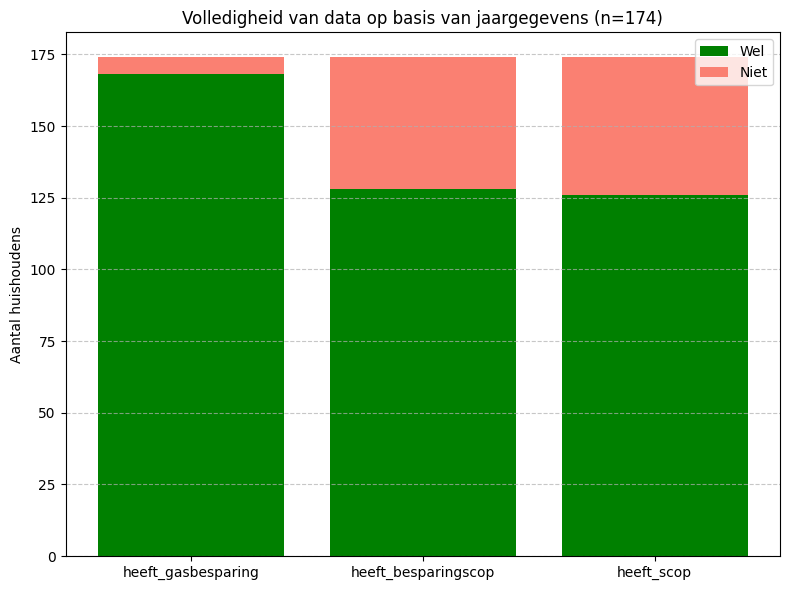

In [27]:
df_yearly_all['heeft_gasbesparing'] = df_yearly_all['gas_consumption_yearly'].notna()                 
df_yearly_all['heeft_besparingscop'] = (df_yearly_all['gas_consumption_yearly'].notna()) & (df_yearly_all['elek_consumption_yearly'].notna())
df_yearly_all['heeft_hybride_scop'] = (df_yearly_all['gas_consumption_yearly'].notna()) & (df_yearly_all['elek_consumption_yearly'].notna()) & (df_yearly_all['energy_out_yearly'].notna())

df_data = df_yearly_all[['heeft_gasbesparing',  'heeft_besparingscop', 'heeft_hybride_scop']] 
# Count the number of True values in each column
true_counts = df_data.sum()
false_counts = df_data.shape[0] - true_counts

# Plotting
plt.figure(figsize=(8, 6))
p1 = plt.bar(true_counts.index, true_counts, color='green', label='Wel')
p2 = plt.bar(false_counts.index, false_counts, bottom=true_counts, color='salmon', label='Niet')
plt.title(f'Volledigheid van data op basis van jaargegevens (n={len(df_yearly_all)})')
plt.ylabel('Aantal huishoudens')
plt.xticks(true_counts.index, ['heeft_gasbesparing', 'heeft_besparingscop', 'heeft_scop'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.legend()
plt.savefig('plots/png/populatie_info/volledigheid_jaargegevens[5].png', dpi=150, transparent=False, facecolor='w', bbox_inches='tight') 
plt.show()

## Manual filtering of weird edge cases

In [28]:
# Special cases that are left out, for more explanation see final report
vervalt_ids = [
    'nkMckb09', # swapped hybrid heatpump 1.5w – bcop kan niet – hybride recent gewisseld – vervalt
    'yV4lUIbS', # too little data, only could do a very rough estimate of gas consumption 
    'zskLB4tU', # historische energierekening klopt niet 880 en 80
    'LzZTAYkZ', # really too little data, could do a very roguth estimate of all 3 totals (115 days)
    '0XvCtU3v', # broken kamstrup (very weird energy_out) 
    '66lZ2dKl', # really too little data, could do a very roguth estimate of all 3 totals (30 days)
    'DlCdUGP1', # broken kamstrup (very weird energy_out) 
]


df_yearly_all['vervalt_wegens'] = ''
df_yearly_all["vervalt"] = 0

df_yearly_all.loc[df_yearly_all.participant_id.isin(vervalt_ids), 'vervalt_wegens'] = 'Handmatig eruit'
df_yearly_all.loc[df_yearly_all.participant_id.isin(vervalt_ids), "vervalt"] = 1

too_little_data = (~df_yearly_all['heeft_gasbesparing']) & (~df_yearly_all['heeft_besparingscop']) & (~df_yearly_all['heeft_hybride_scop'])

# Use np.where to conditionally append the new value
df_yearly_all.loc[too_little_data, 'vervalt_wegens'] += "Te weinig data",
df_yearly_all.loc[too_little_data, 'vervalt'] = 1

print(f'{len(df_yearly_all.loc[too_little_data, ])} # Nr of IDs removed due to missing all yearly totals (lack of data)')
print(f"{len(set(df_yearly_all.loc[too_little_data, 'participant_id']) - set(vervalt_ids))} # Nr of IDs removed due to special cases")  

6 # Nr of IDs removed due to missing all yearly totals (lack of data)
6 # Nr of IDs removed due to special cases


In [29]:
df_yearly_all

,participant_id,method_gas_days,gas_consumption_yearly,method_gas,note_list,method_elek_days,elek_consumption_yearly,method_elek,method_energy_out_days,energy_out_yearly,method_energy_out,gas_consumption_hot_water_per_day,gas_consumption_heating_yearly,heeft_gasbesparing,heeft_besparingscop,heeft_hybride_scop,vervalt_wegens,vervalt
0,-B51sQOp,365.0,323.220000,Jaar aan data (Gemeten),NaN,NaN,NaN,Te weinig data,365.0,15975.479151,Jaar aan data (Gemeten),0.680426,74.864426,True,False,False,,0
1,-ORiFQC6,365.0,143.920000,Jaar aan data (Gemeten),NaN,365.0,2264.034000,Jaar aan data (Gemeten),365.0,8371.283701,Jaar aan data (Gemeten),0.280968,41.366774,True,True,True,,0
2,-uFUg8jU,365.0,919.631000,Jaar aan data (Gemeten),NaN,365.0,3126.188000,Jaar aan data (Gemeten),365.0,15360.651042,Jaar aan data (Gemeten),1.764368,275.636747,True,True,True,,0
3,0RQyG6WX,365.0,574.156000,Jaar aan data (Gemeten),NaN,365.0,2439.592000,Jaar aan data (Gemeten),365.0,13535.177469,Jaar aan data (Gemeten),0.133377,525.473264,True,True,True,,0
4,0XvCtU3v,365.0,320.254000,Jaar aan data (Gemeten),NaN,365.0,1510.166000,Jaar aan data (Gemeten),365.0,34.722222,Jaar aan data (Gemeten),0.443172,158.496172,True,True,True,Handmatig eruit,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,ywCyyxQF,365.0,645.185000,Jaar aan data (Gemeten),NaN,NaN,NaN,Te weinig data,365.0,14791.244213,Jaar aan data (Gemeten),0.266721,547.831721,True,False,False,,0
170,yxOWx66O,365.0,139.726000,Jaar aan data (Gemeten),NaN,365.0,1465.301000,Jaar aan data (Gemeten),365.0,8335.923032,Jaar aan data (Gemeten),0.048983,121.847293,True,True,True,,0
171,zK4WxULP,365.0,453.666000,Jaar aan data (Gemeten),NaN,365.0,1766.257000,Jaar aan data (Gemeten),365.0,9611.663773,Jaar aan data (Gemeten),0.476214,279.848034,True,True,True,,0
172,zPZ3d57M,365.0,479.893000,Jaar aan data (Gemeten),NaN,365.0,2093.507000,Jaar aan data (Gemeten),365.0,8887.149884,Jaar aan data (Gemeten),0.377810,341.992224,True,True,True,,0


In [30]:
df_yearly_all[df_yearly_all.vervalt == 1][
    ["participant_id", "vervalt", "vervalt_wegens"]
]

,participant_id,vervalt,vervalt_wegens
4,0XvCtU3v,1,Handmatig eruit
28,66lZ2dKl,1,Handmatig eruit
47,DlCdUGP1,1,Handmatig eruit
59,IF9c6c-H,1,Te weinig data
63,Jr9PJjgK,1,Te weinig data
70,LzZTAYkZ,1,Handmatig eruit
129,gmtO-ZIa,1,Te weinig data
139,nkMckb09,1,Handmatig eruit
145,qBr4JQ_w,1,Te weinig data
153,uQLTOCT9,1,Te weinig data


In [31]:
# When visualizing results in next section, exclude house holds that we want to take out.
df_yearly_all_filtered = df_yearly_all[df_yearly_all.vervalt == 0]

# Visualizing Results

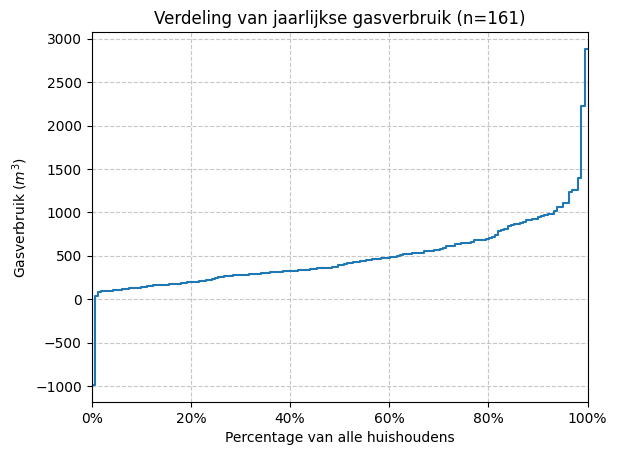

In [32]:
Path("plots/png/populatie_info/jaarlijkse_statistieken").mkdir(parents=True, exist_ok=True)
import matplotlib.ticker as mtick

sns.ecdfplot(data=df_yearly_all_filtered, y="gas_consumption_yearly")
ax = plt.gca()
plt.title(f'Verdeling van jaarlijkse gasverbruik (n={len(df_yearly_all_filtered[df_yearly_all_filtered.gas_consumption_yearly.notnull()])})') 
ax.set_ylabel('Gasverbruik ($m^3$)') 
ax.set_xlabel(f'Percentage van alle huishoudens') 
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('plots/png/populatie_info/jaarlijkse_statistieken/verdeling_van_jaarlijks_gasverbruik[5].png', dpi=150, transparent=False, facecolor='w', bbox_inches='tight')
plt.show()

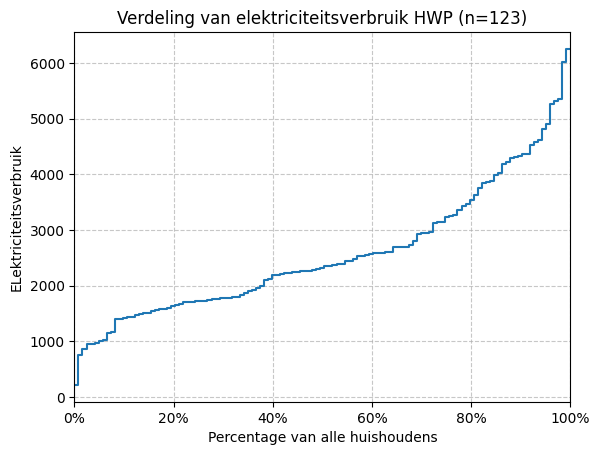

In [33]:
temp = df_yearly_all_filtered.copy(deep=True)
temp['energy_out_yearly'] = temp['energy_out_yearly']*1000

sns.ecdfplot(data=temp, y="elek_consumption_yearly")
ax = plt.gca()
plt.title(f'Verdeling van elektriciteitsverbruik HWP (n={len(temp[temp.elek_consumption_yearly.notnull()])})') 
ax.set_ylabel('ELektriciteitsverbruik') 
ax.set_xlabel(f'Percentage van alle huishoudens') 
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('plots/png/populatie_info/jaarlijkse_statistieken/verdeling_van_jaarlijks_elektriciteitsverbruik_warmtepomp[5].png', dpi=150, transparent=False, facecolor='w', bbox_inches='tight')
plt.show()

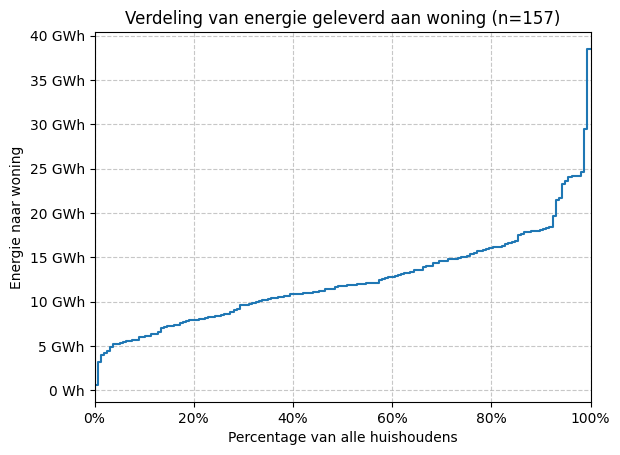

In [34]:
temp['energy_out_yearly'] = temp['energy_out_yearly']*1000
sns.ecdfplot(data=temp, y="energy_out_yearly")
ax = plt.gca()
plt.title(f'Verdeling van energie geleverd aan woning (n={len(df_yearly_all_filtered[df_yearly_all_filtered.energy_out_yearly.notnull()])})') 
ax.set_ylabel('Energie naar woning') 
ax.set_xlabel(f'Percentage van alle huishoudens') 
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.EngFormatter(unit='Wh'))
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('plots/png/populatie_info/jaarlijkse_statistieken/verdeling_van_energie_naar_woning[5].png', dpi=150, transparent=False, facecolor='w', bbox_inches='tight')
plt.show()

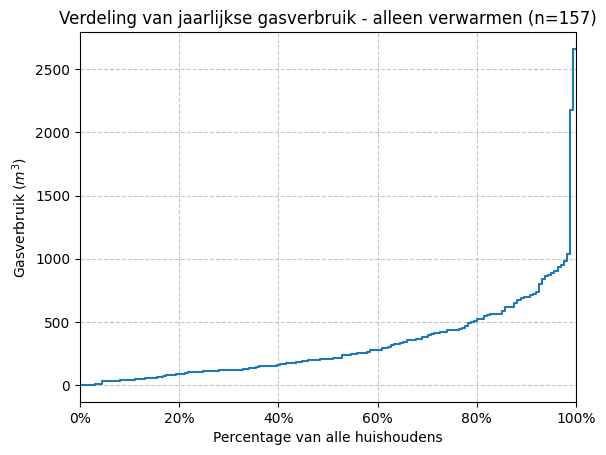

In [35]:
sns.ecdfplot(data=df_yearly_all_filtered, y="gas_consumption_heating_yearly")
ax = plt.gca()
plt.title(f'Verdeling van jaarlijkse gasverbruik - alleen verwarmen (n={len(df_yearly_all_filtered[df_yearly_all_filtered.energy_out_yearly.notnull()])})') 
ax.set_ylabel('Gasverbruik ($m^3$)') 
ax.set_xlabel(f'Percentage van alle huishoudens') 
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('plots/png/populatie_info/jaarlijkse_statistieken/verdeling_van_jaarlijks_gasverbruik_alleen_verwarmen[5].png', dpi=150, transparent=False, facecolor='w', bbox_inches='tight')
plt.show()

# Calculate yearly rendement
Compute the performance of the hybrid heatpump system. This is the energy put into the house devided by the energy consumption of the Hybrid-HP to transport this energy. In later notebooks we also refer to this as 'Seasonal coeficient of performance' of the system or SCOP_Systeem. It's the performance of the heatpump measured over an entire year.

In [36]:
df_temp = df_yearly_all_filtered.copy()
df_temp['energy_gas_yearly'] = df_temp['gas_consumption_heating_yearly'] * 9.77 # compute energy supplied by gas (heating only)  
df_temp['energy_in_yearly'] = df_temp['elek_consumption_yearly'] + df_temp['energy_gas_yearly'] # compute total energy delivered by heatpump 
df_temp['scop_systeem'] = df_temp['energy_out_yearly'] / df_temp['energy_in_yearly'] # SCOP Systeem = jaarlijkse thermische energie verwarmen geleverd / jaarlijkse totale energie verbruikt (gas + elektra)

df_temp = df_temp.dropna(subset=['participant_id', 'energy_gas_yearly', 'energy_in_yearly', 'scop_systeem'])

df_consumption = df_temp
df_consumption = df_consumption.sort_values(by='scop_systeem', ascending=True)
df_consumption

,participant_id,method_gas_days,gas_consumption_yearly,method_gas,note_list,method_elek_days,elek_consumption_yearly,method_elek,method_energy_out_days,energy_out_yearly,...,gas_consumption_hot_water_per_day,gas_consumption_heating_yearly,heeft_gasbesparing,heeft_besparingscop,heeft_hybride_scop,vervalt_wegens,vervalt,energy_gas_yearly,energy_in_yearly,scop_systeem
8,141Q2Shj,266.0,700.000,Handmatig (Schatting),NaN,266.0,2370.000,Handmatig (Schatting),153.0,6000.000000,...,0.382738,560.300738,True,True,True,,0,5474.138207,7844.138207,0.764902
56,HedOCi6L,365.0,183.115,Jaar aan data (Gemeten),NaN,365.0,214.800,Jaar aan data (Gemeten),365.0,628.055556,...,0.352663,54.392837,True,True,True,,0,531.418013,746.218013,0.841652
161,wEqq3ifR,365.0,2882.813,Jaar aan data (Gemeten),NaN,365.0,5359.546,Jaar aan data (Gemeten),365.0,29464.409722,...,0.605182,2661.921636,True,True,True,,0,26006.974387,31366.520387,0.939359
140,on1VMMTO,365.0,2228.903,Jaar aan data (Gemeten),NaN,365.0,2476.424,Jaar aan data (Gemeten),365.0,24206.785301,...,0.144614,2176.119023,True,True,True,,0,21260.682852,23737.106852,1.019787
30,6oWZr5LM,365.0,1256.051,Jaar aan data (Gemeten),NaN,365.0,1394.669,Jaar aan data (Gemeten),365.0,11924.751157,...,0.610379,1033.262552,True,True,True,,0,10094.975130,11489.644130,1.037869
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,ez7d4xNY,365.0,167.219,Jaar aan data (Gemeten),NaN,365.0,2535.673,Jaar aan data (Gemeten),365.0,11397.433449,...,0.364459,34.191297,True,True,True,,0,334.048975,2869.721975,3.971616
146,qdC1C7Lx,365.0,126.502,Jaar aan data (Gemeten),NaN,365.0,1779.378,Jaar aan data (Gemeten),365.0,8217.847222,...,0.271346,27.460654,True,True,True,,0,268.290588,2047.668588,4.013270
23,5GCcwjbF,365.0,34.478,Jaar aan data (Gemeten),NaN,365.0,2952.713,Jaar aan data (Gemeten),365.0,12091.134259,...,0.080873,4.959398,True,True,True,,0,48.453321,3001.166321,4.028812
103,aQ1RbqD6,365.0,79.050,Jaar aan data (Gemeten),NaN,365.0,2265.011,Jaar aan data (Gemeten),365.0,10361.929977,...,0.134717,29.878302,True,True,True,,0,291.911009,2556.922009,4.052501


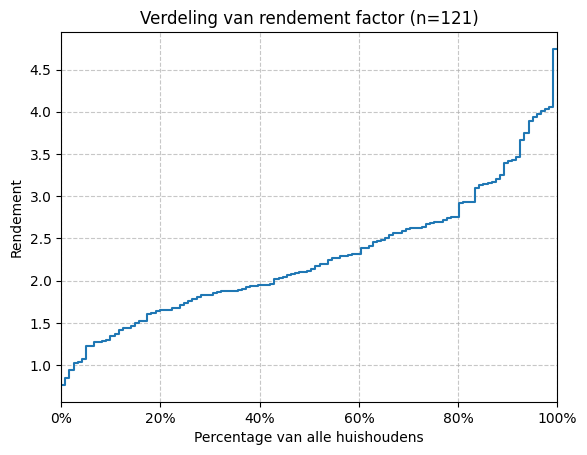

In [37]:
sns.ecdfplot(data=df_consumption, y="scop_systeem")
ax = plt.gca()
plt.title(
    f"Verdeling van rendement factor (n={len(df_consumption[df_consumption.scop_systeem.notnull()])})"
)
ax.set_ylabel("Rendement")
ax.set_xlabel(f"Percentage van alle huishoudens")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(True, linestyle="--", alpha=0.7)
plt.savefig(
    "plots/png/populatie_info/jaarlijkse_statistieken/verdeling_van_rendement[5].png",
    dpi=150,
    transparent=False,
    facecolor="w",
    bbox_inches="tight",
)
plt.show()

In [38]:
from pathlib import Path
Path("cache/step5/").mkdir(parents=True, exist_ok=True)

df_list = [
    (df_yearly_all, "df_yearly"),
    (df_opmerkingen, "df_opmerkigen"),
]

for df_tuple in df_list: 
    df = df_tuple[0]
    name = df_tuple[1] 
    df.to_parquet(f"cache/step5/{name}.parquet", engine='pyarrow');
    print(f"Created .parquet file for {name}, length: {len(df)}") 
    
# Add a text file which notes when we last ran this code: 
filepath = 'cache/step5/notebook_5_last_run_date.txt'

with open(filepath, 'w') as file:
    file.write(datetime.now().strftime('%Y-%m-%d %H:%M:%S'))

Created .parquet file for df_yearly, length: 174
Created .parquet file for df_opmerkigen, length: 82
